## ライブラリの取り込み

In [8]:
%matplotlib inline
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from filterpy.gh import GHFilter
from numpy.random import randn
import seaborn as sns
import tqdm
import pickle as pkl
import os
import os.path as osp

from utils import *
from kf_params import *

## KalmanFilterの結果の読み込み

In [4]:
num_data = 4
#path = "data/kalman_log/20160919_00_14/"
path = "data/saver/"
kalman_ress = [] 
jcope_obss = []
for i in range(num_data):
    kalman_ress.append(pkl.load(open(path+f"saverX{i+1}.pkl", "rb")))
    jcope_obss.append(pkl.load(open(path+f"saverZ{i+1}.pkl", "rb")))
kalman_res = kalman_ress[-1]
jcope_obs = jcope_obss[-1]

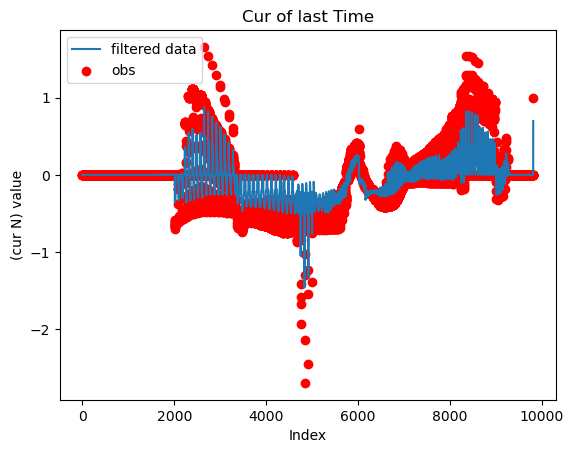

39236

In [5]:
plt.title("Cur of last Time")
plt.xlabel("Index")
plt.ylabel(f"(cur N) value")
plt.plot(np.arange(len(np.array(kalman_res)[-1])), np.array(kalman_res)[-1], label=f'filtered data')
plt.scatter(np.arange(len(np.array(kalman_res)[-1])), np.array(jcope_obs)[-1], label=f'obs', c='r')
plt.legend()
plt.show()
np.sum(np.array(kalman_res) == np.array(kalman_res))

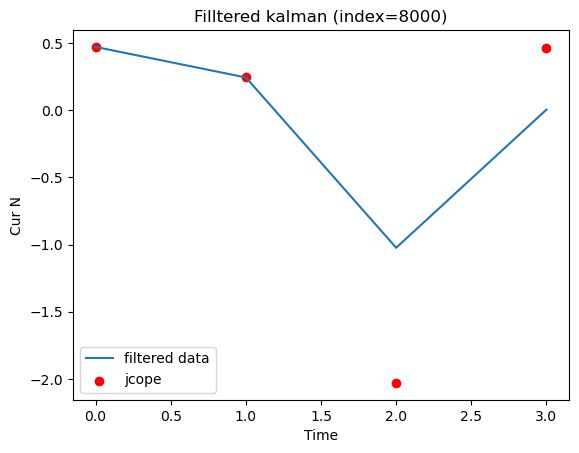

39236

In [6]:

#print(f"s.x {s.x}")
#print(f"s.z {s.z}")
i = 8000
dataX = np.array(kalman_res).T
dataX = dataX[0][i]
dataZ = np.array(jcope_obs).T
dataZ = dataZ[0][i]

plt.title(f"Filltered kalman (index={i})")
plt.xlabel("Time")
plt.ylabel(f"Cur N")
plt.plot(np.arange(len(dataX)), dataX, label=f'filtered data')
plt.scatter(np.arange(len(dataX)), dataZ, label=f'jcope', c='r')
plt.legend()
plt.show()
np.sum(np.array(kalman_res) == np.array(kalman_res))

## 各船の偏流の実測値

In [10]:
path_log = "./data/shipLog/2016-0919/中春"
filename = "cur_hours.csv"
shipLog = pd.read_csv(open(osp.join(path_log, filename), encoding="cp932",))
shipLog

,Unnamed: 0,DtIdx,CurN,CurE,Grid0,Grid1,Lat,Lon
0,0,0,0.042129,0.096316,515,600,35.732909,133.644939
1,1,1,0.122788,-0.041919,514,609,35.758788,133.890163
2,2,2,0.188681,-0.059161,513,617,35.781539,134.133786
3,3,3,0.173578,-0.175094,513,626,35.805412,134.378779
4,4,4,0.316185,-0.110851,512,635,35.829486,134.613173
5,5,5,0.557288,-0.074536,511,642,35.838264,134.830758
6,6,6,0.136415,-0.008944,511,650,35.841704,135.045435
7,7,7,0.024775,0.537530,512,657,35.825286,135.249817
8,8,8,-0.390569,0.467307,517,661,35.691732,135.349689
9,9,9,-0.122021,0.543341,523,661,35.526039,135.333941


In [9]:
real_cur_mapN = []
#time_set = set(real_cur['DtIdx'].values)
time_set = set([0])
for i in time_set:
    data = real_cur[real_cur["DtIdx"]==i]
    lat_lon_set = set(data["LatIdx"].astype(str) + " " 
                       + data["LonIdx"].astype(str))
    target_mapN = np.zeros(map_size_ais)
    for lat_lon in tqdm.tqdm(lat_lon_set):
        target_tf = (lat_lon == data["LatIdx"].astype(str) + " " 
                                  + data["LonIdx"].astype(str))
        target = data[target_tf]
        lat = target["LatIdx"].values[0]
        lat = map_size_ais[0]-lat
        lon = target["LonIdx"].values[0]
        if lat<0 or lat>map_size_ais[0]: continue
        if lon<0 or lon>map_size_ais[1]: continue
        rad = azimuth_to_radian(target["CurDir"])
        target_mapN[lat][lon] = np.mean(target["CurMag"]*np.sin(rad))
    real_cur_mapN.append(target_mapN)

  0%|▎                                                                               | 31/7810 [00:14<58:45,  2.21it/s]


KeyboardInterrupt: 

In [10]:
p = fr'./data/eas\2015091900{0}'
jcope = pd.read_csv(p+"/N.csv", encoding="cp932",)
nan_map = np.array(jcope.values)*0+1

In [11]:
diff = 20
datas = [real_cur_mapN[0], real_cur_mapN[0][0:1050-diff]*nan_map[diff:1050]]
data_names = ['real cur', 'real cur with nan map']
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    axes[i].set_aspect('equal', adjustable='box')
    axes[i].set_title(data_names[i], fontsize=20)
    axes[i].set_xlim(0, 1050)
    axes[i].set_ylim(0, 1090)
    sns.heatmap(data, ax=axes[i])
plt.show()

IndexError: list index out of range

In [ ]:
datas = [real_cur_mapN[0]]
data_names = ['real cur', 'real cur with nan map']
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 8))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    axes.set_aspect('equal', adjustable='box')
    axes.set_title(data_names[i], fontsize=20)
    axes.set_xlim(0, 1050)
    axes.set_ylim(0, 1090)
    sns.heatmap(data, ax=axes)
plt.show()

real cur:(1050, 1191)


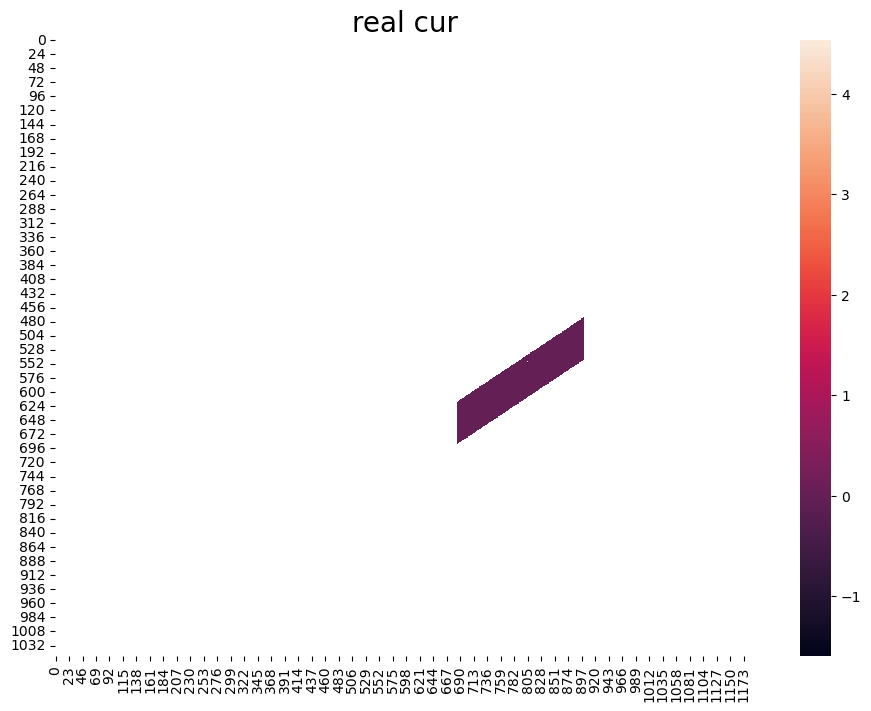

In [166]:
diff = 0
datas = [real_cur_mapN[0][0:1050-diff]*kurosio_map[diff:1050]]
data_names = ['real cur', 'real cur with nan map']
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 8))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    axes.set_aspect('equal', adjustable='box')
    axes.set_title(data_names[i], fontsize=20)
    axes.set_xlim(0, 1050)
    axes.set_ylim(0, 1090)
    sns.heatmap(data, ax=axes)
plt.show()

real cur:(1020, 1191)


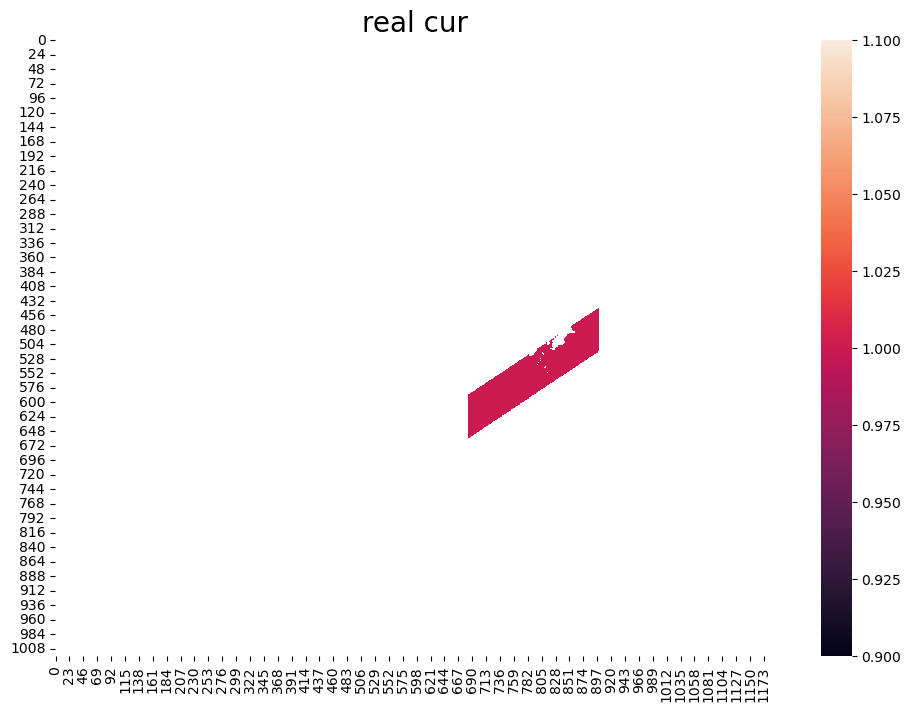

In [167]:
diff = 30
datas = [kurosio_map[diff:1050]*nan_map[diff:1050]]
data_names = ['real cur', 'real cur with nan map']
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 8))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    axes.set_aspect('equal', adjustable='box')
    axes.set_title(data_names[i], fontsize=20)
    axes.set_xlim(0, 1050)
    axes.set_ylim(0, 1090)
    sns.heatmap(data, ax=axes)
plt.show()